## Libraries Used

In [70]:
import evaluate
import pandas as pd
import seaborn as sns
import transformers
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers.trainer_utils import EvalPrediction

transformers.logging.set_verbosity_error()

## Setup...

In [71]:
import sys

is_colab = "google.colab" in sys.modules
if is_colab:
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    OUT_DIR = "./drive/MyDrive/Colab Notebooks/ModernBert"
else:
    OUT_DIR = "./ModernBert"

# instantiate the model
NAME = "answerdotai/ModernBERT-base"

In [79]:
def get_frozen_model():
    model = transformers.AutoModelForSequenceClassification.from_pretrained(
        NAME,
        dtype="auto",
        num_labels=2,
    )
    for param in model.base_model.parameters():
        param.requires_grad_(False)
    return model


# set up the dataset and dataset loading
tokenizer = transformers.AutoTokenizer.from_pretrained(NAME)
ds_raw = load_dataset("stanfordnlp/sst2")

# tokenize the dataset entries
ds = ds_raw.map(
    lambda item: tokenizer(
        item["sentence"],
        truncation=True,
        max_length=512,
    )
)

# batch collator
collator = transformers.DataCollatorWithPadding(tokenizer)

# accuracy setup
accuracy = evaluate.load("accuracy")


def calc_accuracy(p: EvalPrediction) -> dict:
    return accuracy.compute(
        predictions=p.predictions.argmax(axis=-1),  # type: ignore
        references=p.label_ids,
    )


def get_trainer(model, type: str):
    training_args = transformers.TrainingArguments(
        output_dir=f"{OUT_DIR}/{type}",
        num_train_epochs=4,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        bf16=True,
        learning_rate=2e-5,
        eval_strategy="steps",
        eval_steps=1000,
        save_strategy="steps",
        save_steps=1000,
        load_best_model_at_end=True,
        disable_tqdm=False,
    )

    return transformers.Trainer(
        model,
        args=training_args,
        train_dataset=ds["train"],
        eval_dataset=ds["validation"],
        compute_metrics=calc_accuracy,
        processing_class=tokenizer,
        data_collator=collator,
    )

## Head Tuning

### Training

In [80]:
model = get_frozen_model()
trainer = get_trainer(model, "head_tuning")
trainer.train(resume_from_checkpoint=True)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss


TrainOutput(global_step=16840, training_loss=0.0, metrics={'train_runtime': 0.0155, 'train_samples_per_second': 17346956.728, 'train_steps_per_second': 1084361.874, 'total_flos': 3511377825746616.0, 'train_loss': 0.0, 'epoch': 4.0})

### Results

#### High Training Loss

Getting the results from the trainer...

In [81]:
ht_df = (
    pd.DataFrame(trainer.state.log_history)
    .groupby(["epoch", "step"], as_index=False)
    .first()
)  # group since the training and eval measurements are contained in separate entries
ht_df.head()

,epoch,step,grad_norm,learning_rate,loss,eval_accuracy,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.118782,500,23.557270,0.000019,5.159896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.237565,1000,22.929781,0.000019,4.613239,0.768349,0.529529,6.3384,137.574,17.197,NaN,NaN,NaN,NaN,NaN
2,0.356347,1500,16.120594,0.000018,4.356226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.475130,2000,18.733170,0.000018,4.126254,0.779817,0.487601,6.3441,137.451,17.181,NaN,NaN,NaN,NaN,NaN
4,0.593912,2500,12.776261,0.000017,4.017974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The loss does not seem right. I asked Gemini what the cause could be of this and gave it the definition of my `get_trainer` method. It said that the cause was setting `gradient_accumulation_steps=8` (i.e. the training loss was the sum over those 8 steps instead of the mean). That seems plausible if we look at the loss divided by 8: 

In [82]:
ht_df['loss'] / 8

0     0.644987
1     0.576655
2     0.544528
3     0.515782
4     0.502247
5     0.488579
6     0.481877
7     0.473219
8     0.468507
9     0.461451
10    0.458144
11    0.452382
12    0.458838
13    0.443392
14    0.446163
15    0.440481
16    0.436760
17    0.448023
18    0.441008
19    0.437435
20    0.436702
21    0.438272
22    0.437622
23    0.432299
24    0.425628
25    0.431231
26    0.428035
27    0.437202
28    0.426696
29    0.427903
30    0.423132
31    0.438390
32    0.437507
33         NaN
Name: loss, dtype: float64

which looks to be in the right ballpark. And if I train with the `gradient_accumulation_steps` set to 1:

In [83]:
test_model = get_frozen_model()
test_trainer = get_trainer(model, 'sft_grad_accumulation_1')
test_trainer.args.max_steps=1000 # only do one loss evaluation
test_trainer.args.gradient_accumulation_steps=1
test_trainer.train(resume_from_checkpoint=True)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss,Accuracy
1000,0.435216,0.418550,0.810780


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.44084457397460936, metrics={'train_runtime': 52.5693, 'train_samples_per_second': 38.045, 'train_steps_per_second': 19.022, 'total_flos': 26095928012280.0, 'train_loss': 0.44084457397460936, 'epoch': 0.02969561989606533})

We also get in the same ballpark. It seems reasonable now to assume that the training loss is summed over 8 steps. It may be possible that changing it improved the model's training loss that much, though this is doubtful since validation loss didn't differ by much.

So to avoid retraining, training loss below will be divided by 8 (both for fine-tuning the head, and for LoRA).

In [94]:
ht_df_norm = ht_df.assign(loss=ht_df['loss'] / 8)

#### Plot

Then plotting the model performance over training:

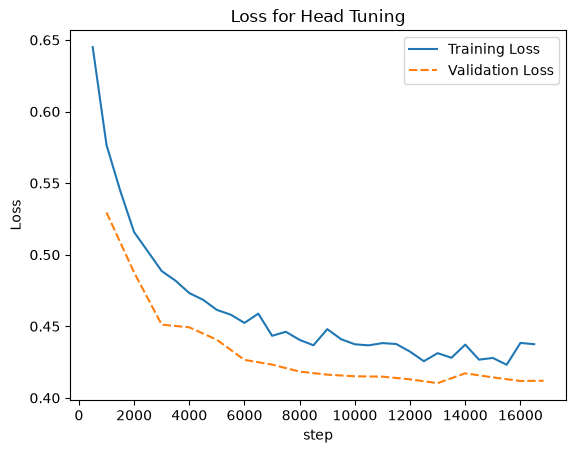

In [95]:
ax = sns.lineplot(ht_df_norm[['step', 'loss', 'eval_loss']].set_index('step'))
ax.set_ylabel("Loss")
ax.set_title("Loss for Head Tuning")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Training Loss', 'Validation Loss']);

## LoRA

Let's see how many trainable params the head tuning model had...

In [97]:
trainer.get_num_trainable_parameters()

592130

Now let's see what we can get with LoRA. This will have low-rank updates for the classifier and head (same as in 4.1), but also for the attention matrices throughout the model.

In [98]:
lora_config = LoraConfig(
    r=8,
    task_type=TaskType.SEQ_CLS,
    target_modules=['Wqkv', 'classifier', 'head.dense']
)
lora_model = get_peft_model(get_frozen_model(), lora_config)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

Then the number of trainable parameters for this is:

In [88]:
lora_model.get_nb_trainable_parameters()[0]

554498

So we have about 50000 fewer parameters - that's in the same ballpark.

Now let's train...

In [99]:
lora_trainer = get_trainer(lora_model, 'lora')
lora_trainer.train(resume_from_checkpoint=True)

Step,Training Loss,Validation Loss


TrainOutput(global_step=16840, training_loss=0.0, metrics={'train_runtime': 0.0011, 'train_samples_per_second': 250427464.624, 'train_steps_per_second': 15654272.908, 'total_flos': 3528930888009072.0, 'train_loss': 0.0, 'epoch': 4.0})

### Results

Get the loss over time...

In [100]:
lora_df = (
    pd.DataFrame(lora_trainer.state.log_history)
    .groupby(["epoch", "step"], as_index=False)
    .first()
)
lora_df_norm = lora_df.assign(loss=lora_df["loss"] / 8)
lora_df_norm.head()

,epoch,step,grad_norm,learning_rate,loss,eval_accuracy,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.118782,500,15.668808,0.000019,0.677213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.237565,1000,44.599457,0.000019,0.624844,0.697248,0.590522,6.7730,128.747,16.093,NaN,NaN,NaN,NaN,NaN
2,0.356347,1500,29.062616,0.000018,0.542968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.475130,2000,28.363882,0.000018,0.426781,0.818807,0.401517,6.6729,130.678,16.335,NaN,NaN,NaN,NaN,NaN
4,0.593912,2500,38.497570,0.000017,0.358961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Plot

And then plotting...

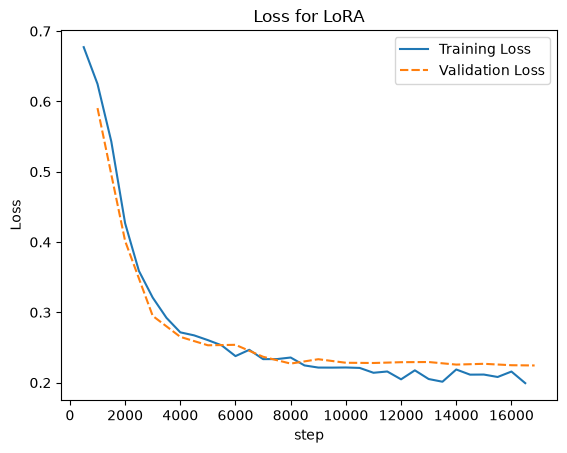

In [101]:
ax = sns.lineplot(lora_df_norm[['step', 'loss', 'eval_loss']].set_index('step'))

ax.set_ylabel("Loss")
ax.set_title("Loss for LoRA")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Training Loss', 'Validation Loss']);

## Top Validation Accuracy

Below is the table for the top validation accuracy for each approach; it is also copied to the typeset hw.

In [93]:
table1 = pd.DataFrame([
    {
        "Approach": "Head Tuning",
        "Accuracy (validation)": ht_df_norm["eval_accuracy"].max(),
    },
    {
        "Approach": "LoRA",
        "Accuracy (validation)": lora_df_norm["eval_accuracy"].max(),
    }
])

table_str = table1.style.hide().format()
table_str

Approach,Accuracy (validation)
Head Tuning,0.819954
LoRA,0.927752
